# Q1 : Passive Membrane Model


Resistance $R$ = $40 M \Omega = 40 \times 10^6 \Omega$ </br>
Capacitance $C$ = $1 nF = 10^{-9} F$ </br>
Resting potential $u_{rest} = -65mV = -65 \times 10^{-3} V$

$$
\text{Current } I(t) =
\begin{cases}
0, & t < 100\text{ ms} \\
0.5\text{ nA}, & 100\text{ ms} \le t \lt 600\text{ ms} \\
0, & t \ge 600\text{ ms}
\end{cases}
$$


In [72]:
# Basic Libraries
import matplotlib.pyplot as plt
import numpy as np

In [73]:
R = 4e7  # Resistance
C = 1e-9  # Capacitance
u_rest = -65e-3  # Resting potential
I_t = lambda t: 5e-10 if (1e-1 <= t < 6e-1) else 0.0  # Input current
tau = R * C  # Characteristic constant

Now, from the passive membrane model equation,

$$
\frac{du(t)}{dt} = -\frac{u(t) - u_{\text{rest}}}{RC} + \frac{1}{C} I(t)
$$


Using Euler's Integration with time step $\Delta t$ we have,

$$
u(t + \Delta t) = u(t) + \Delta t \left[ -\frac{u(t) - u_{\text{rest}}}{RC} + \frac{1}{C} I(t) \right]
$$


In [74]:
delta_t = 1e-4  # Time step = 0.1ms

## Passive Membrane Model Simulation


In [75]:
def simulate_passive_membrane(u_rest, R, C, I_t, delta_t=1e-4, t_0=0, t_1=1):
    # Store results
    U = []
    I = []
    T = []

    u_t = u_rest  # Intitialize u(t)

    for t in np.arange(t_0, t_1 + delta_t, delta_t):
        i_t = I_t(t)  # Get input current value
        u_t = u_t + delta_t * (-(u_t - u_rest) / (R * C) + i_t / C)  # Euler Integration
        U.append(u_t)
        I.append(i_t)
        T.append(t)

    return np.array(U), np.array(I), np.array(T)


In [76]:
U, I, T = simulate_passive_membrane(u_rest, R, C, I_t, delta_t)

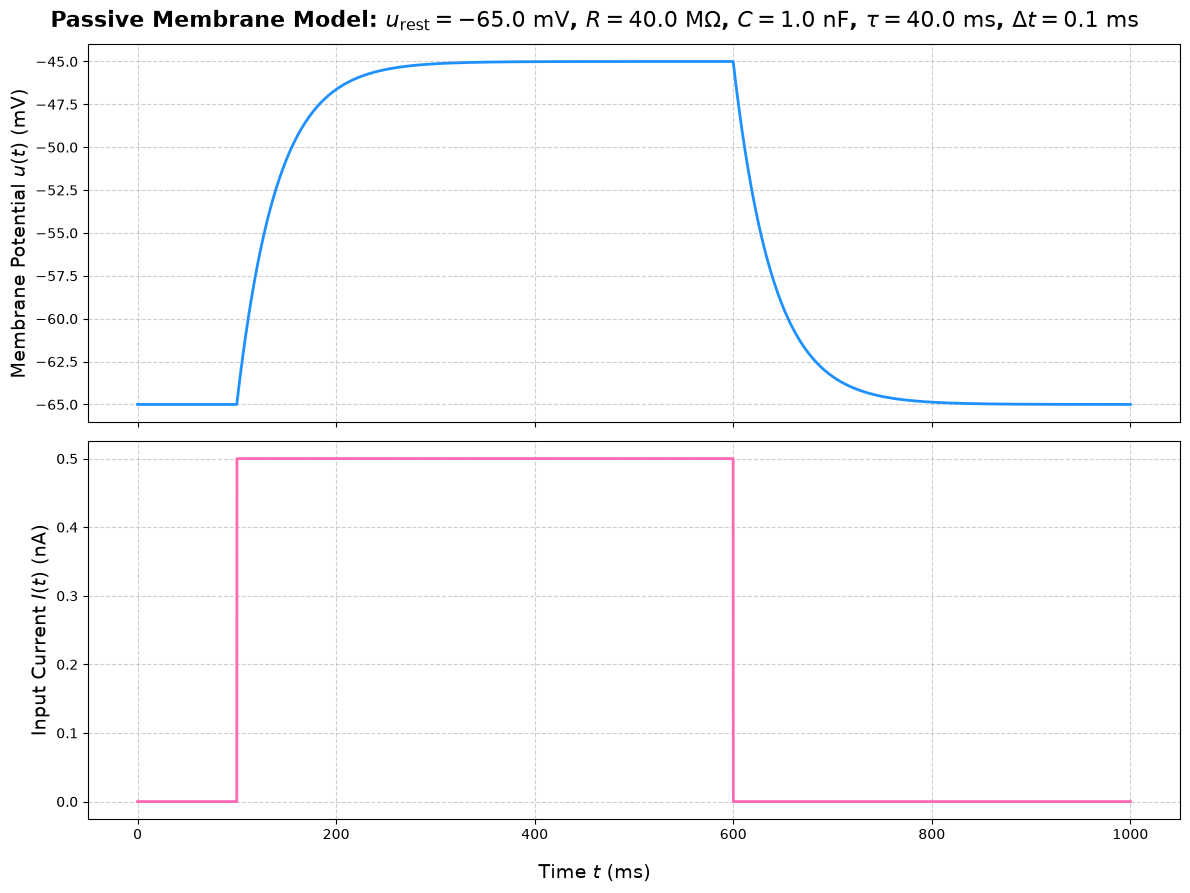

In [77]:
fig, ax = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
fig.suptitle(
    rf"Passive Membrane Model: $u_{{\text{{rest}}}} = {u_rest * 1e3}\text{{ mV}}$, $R = {R / 1e6}\text{{ M}}\Omega$, $C = {C * 1e9}\text{{ nF}}$, $\tau = {tau * 1e3:.1f}\text{{ ms}}$, $\Delta t = {delta_t * 1e3}\text{{ ms}}$",
    fontsize=16,
    fontweight="bold",
)
fig.supxlabel("Time $t$ (ms)", fontsize=14)

ax[0].plot(T * 1e3, U * 1e3, lw=2, c="dodgerblue")
ax[0].set_ylabel(r"Membrane Potential $u(t)$ (mV)", fontsize=14)
ax[0].grid(True, linestyle="--", alpha=0.6)

ax[1].plot(T * 1e3, I * 1e9, lw=2, c="hotpink")
ax[1].set_ylabel(r"Input Current $I(t)$ (nA)", fontsize=14)
ax[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()
fig.savefig("q1_sim.png", dpi=500)

---
